In [ ]:
from google.colab import files
uploaded = files.upload()  # A file picker will appear

Saving Car Sales.csv to Car Sales.csv


In [ ]:
import pandas as pd
df = pd.read_csv("Car Sales.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [ ]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('($)', '', regex=False)

In [ ]:
df.rename(columns={'Price_': 'Price'}, inplace=True)

In [ ]:
df.isnull().sum()

,0
Car_id,0
Date,0
Customer_Name,1
Gender,0
Annual_Income,0
Dealer_Name,0
Company,0
Model,0
Engine,0
Transmission,0


In [ ]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Company'] = df['Company'].fillna(df['Company'].mode()[0])

df.dropna(subset=['Price'], inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

In [ ]:
df = df[df['Price'] < df['Price'].quantile(0.99)]

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.drop(columns=['Phone', 'Dealer_No'], inplace=True)

In [ ]:
print(df.columns.tolist())

['Car_id', 'Date', 'Customer_Name', 'Gender', 'Annual_Income', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Price', 'Body_Style', 'Dealer_Region']


In [ ]:
df.columns


Index(['Car_id', 'Date', 'Customer_Name', 'Gender', 'Annual_Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price', 'Body_Style', 'Dealer_Region'],
      dtype='object')

In [ ]:
import numpy as np

# 1. Price Category (Low / Mid / High)
df['Price_Category'] = pd.cut(df['Price'],
                               bins=3,
                               labels=['Low', 'Mid', 'High'])

# 2. Affordability Ratio (Price vs Annual Income)
df['Affordability_Ratio'] = round(df['Price'] / df['Annual_Income'], 2)

# 3. Extract Year and Month from Date
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

# 4. Customer Income Category
df['Income_Category'] = pd.cut(df['Annual_Income'],
                                bins=3,
                                labels=['Low Income', 'Mid Income', 'High Income'])

# Verify new columns
print(df.columns.tolist())
df.head()

['Car_id', 'Date', 'Customer_Name', 'Gender', 'Annual_Income', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Price', 'Body_Style', 'Dealer_Region', 'Price_Category', 'Affordability_Ratio', 'Year', 'Month', 'Month_Name', 'Income_Category']


,Car_id,Date,Customer_Name,Gender,Annual_Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price,Body_Style,Dealer_Region,Price_Category,Affordability_Ratio,Year,Month,Month_Name,Income_Category
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,Double Overhead Camshaft,Auto,Black,26000,SUV,Middletown,Mid,1.93,2022,1,January,Low Income
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,Double Overhead Camshaft,Auto,Black,19000,SUV,Aurora,Low,0.01,2022,1,January,Low Income
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,Passenger,Greenville,Mid,0.03,2022,1,January,Low Income
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,SUV,Pasco,Low,1.04,2022,1,January,Low Income
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,Double Overhead Camshaft,Auto,Red,24500,Hatchback,Janesville,Low,0.02,2022,1,January,Low Income


In [ ]:
import numpy as np

# 1. Price Category (Low / Mid / High)
df['Price_Category'] = pd.cut(df['Price'],
                               bins=3,
                               labels=['Low', 'Mid', 'High'])

# 2. Affordability Ratio (Price vs Annual Income)
df['Affordability_Ratio'] = round(df['Price'] / df['Annual_Income'], 2)

# 3. Extract Year and Month from Date
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

# 4. Customer Income Category
df['Income_Category'] = pd.cut(df['Annual_Income'],
                                bins=3,
                                labels=['Low Income', 'Mid Income', 'High Income'])

# Verify new columns
print(df.columns.tolist())
df.head()

['Car_id', 'Date', 'Customer_Name', 'Gender', 'Annual_Income', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Price', 'Body_Style', 'Dealer_Region', 'Price_Category', 'Affordability_Ratio', 'Year', 'Month', 'Month_Name', 'Income_Category']


,Car_id,Date,Customer_Name,Gender,Annual_Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price,Body_Style,Dealer_Region,Price_Category,Affordability_Ratio,Year,Month,Month_Name,Income_Category
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,Double Overhead Camshaft,Auto,Black,26000,SUV,Middletown,Mid,1.93,2022,1,January,Low Income
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,Double Overhead Camshaft,Auto,Black,19000,SUV,Aurora,Low,0.01,2022,1,January,Low Income
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,Passenger,Greenville,Mid,0.03,2022,1,January,Low Income
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,SUV,Pasco,Low,1.04,2022,1,January,Low Income
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,Double Overhead Camshaft,Auto,Red,24500,Hatchback,Janesville,Low,0.02,2022,1,January,Low Income


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Car Sales.csv")

print(df.shape)          # rows and columns
print(df.info())         # data types
print(df.describe())     # stats for numeric columns
print(df.isnull().sum()) # missing values

(23906, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB
None
       Annual Income     Price ($)         Phone


In [ ]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

# Strip spaces from column names
df.columns = df.columns.str.strip()

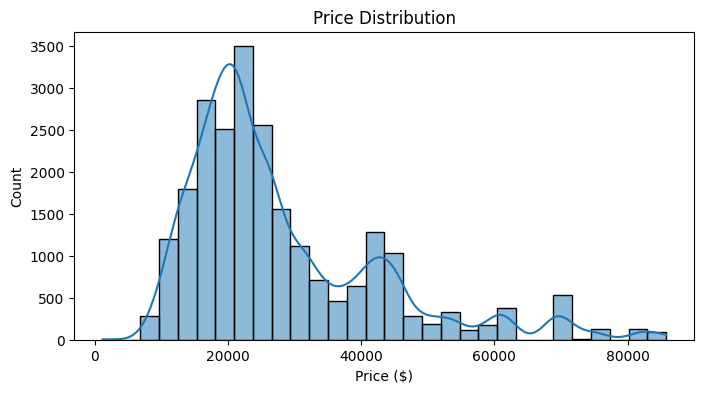

In [ ]:
# Price distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Price ($)'], bins=30, kde=True)
plt.title('Price Distribution')
plt.show()



## Price Distribution
**Key Insight:** Most cars are priced between $18,000–$34,000.
Very few cars are above $60,000, showing the market is mid-range focused.
**Implication:** Mid-range pricing ($20K–$35K) is the sweet spot
for maximum sales volume.

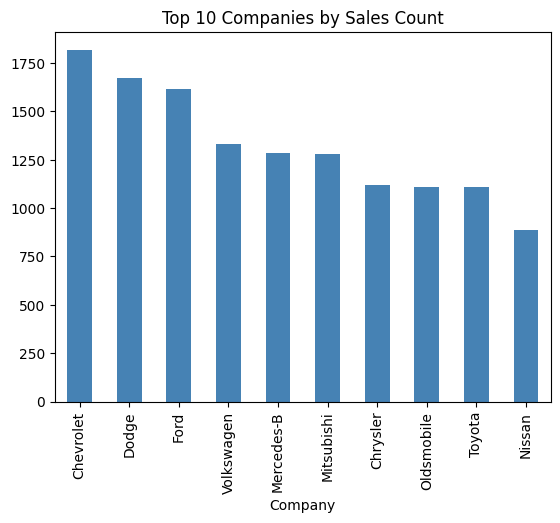

In [ ]:
# Top 10 Car Companies

df['Company'].value_counts().head(10).plot(kind='bar', color='steelblue')

plt.title('Top 10 Companies by Sales Count')

plt.show()

## Top Companies by Sales
**Key Insight:** Chevrolet leads with 1,819 sales, followed by Dodge (1,671)
and Ford (1,614). American brands dominate volume sales.
**Implication:** Dealers should stock more American brand inventory
to meet higher demand.

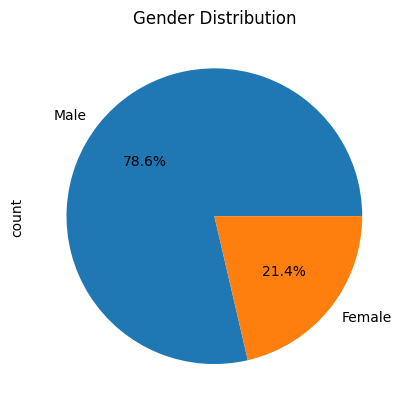

In [ ]:
# Gender split

df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Gender Distribution')

plt.show()

## Gender Distribution
**Key Insight:** 78.6% of buyers are Male and only 21.4% are Female.
**Implication:** Marketing campaigns are likely targeting male audiences.
There is an untapped opportunity in female customer outreach.

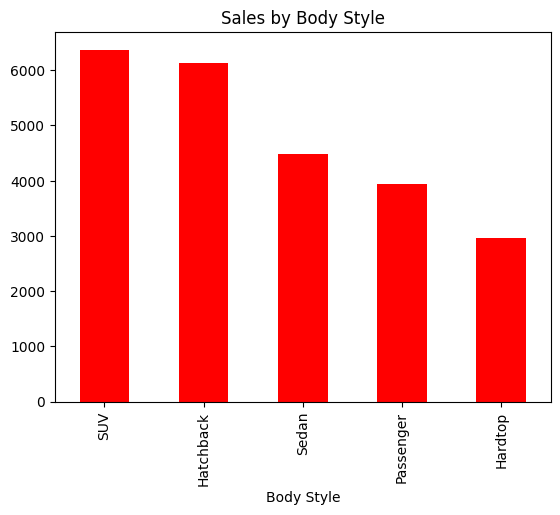

In [ ]:
# Body Style

df['Body Style'].value_counts().plot(kind='bar', color='red')

plt.title('Sales by Body Style')

plt.show()

## Sales by Body Style
**Key Insight:** SUV (6,374) and Hatchback (6,128) are the most popular
body styles, together making up 53% of all sales.
**Implication:** Dealers should prioritize SUV and Hatchback inventory
as they have the highest customer demand.

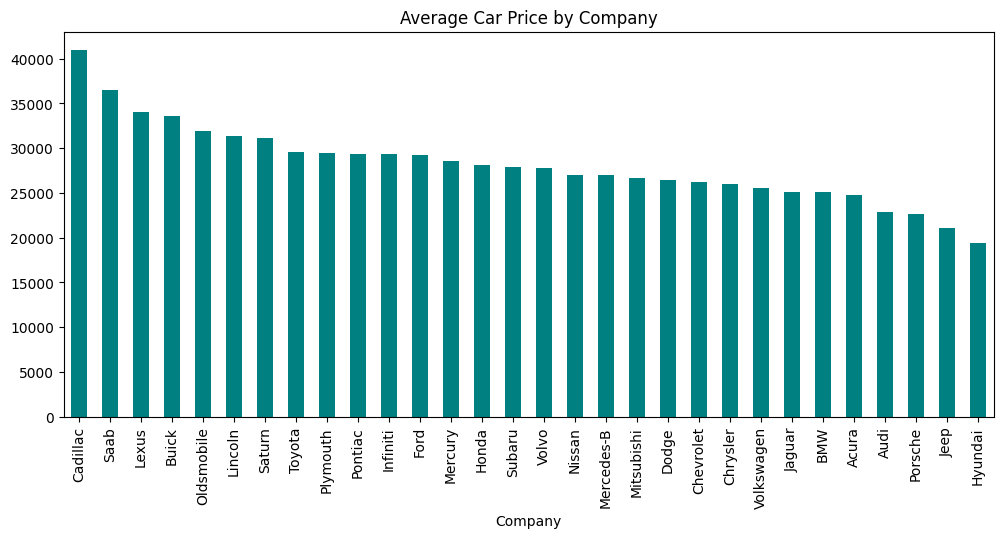

In [ ]:
# Average Price by Company
df.groupby('Company')['Price ($)'].mean().sort_values(ascending=False)\
  .plot(kind='bar', figsize=(12,5), color='teal')
plt.title('Average Car Price by Company')
plt.show()



## Average Price by Company
**Key Insight:** Cadillac has the highest average price at $40,972,
while budget brands like Mitsubishi and Chrysler are priced below $25,000.
**Implication:** Premium brands generate more revenue per sale
despite lower sales volume.

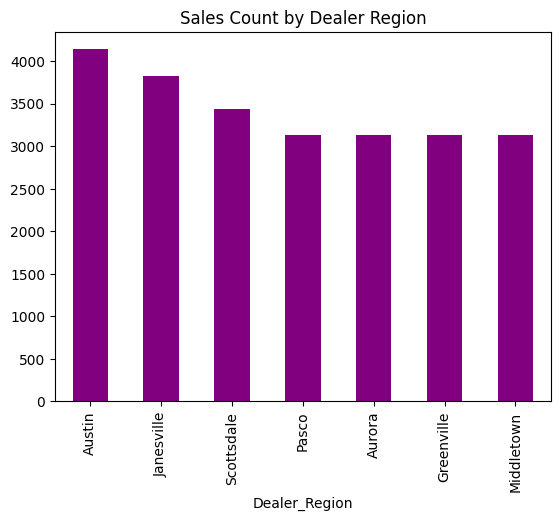

In [ ]:
# Sales by Dealer Region

df['Dealer_Region'].value_counts().plot(kind='bar', color='purple')

plt.title('Sales Count by Dealer Region')

plt.show()

## Insight: Sales by Dealer Region
Austin leads with 4,135 sales — the highest among all 7 regions.
The bottom 4 regions are nearly equal in sales count (~3,128 each),
suggesting untapped growth potential there. Chevrolet is the dominant
brand in 6 out of 7 regions. SUV is the preferred body style in most
regions, except Janesville and Middletown where Hatchbacks lead.
Pricing is consistent across all regions with less than $510 difference.

Saving Car Sales.csv to Car Sales (1).csv


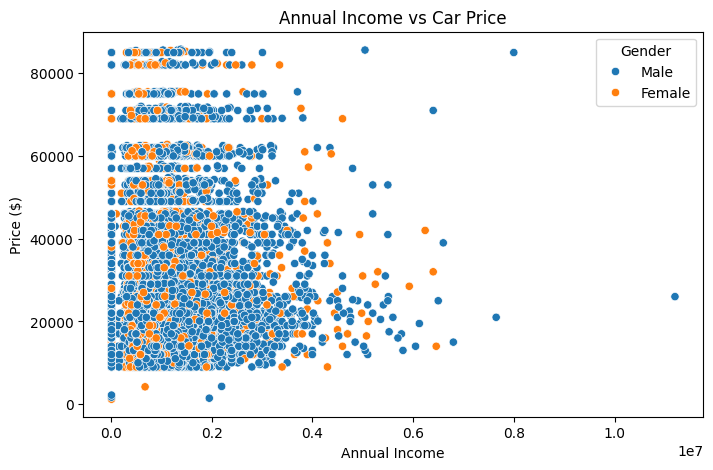

In [ ]:
from google.colab import files
uploaded = files.upload()  # choose Car Sales.csv from your computer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Car Sales.csv")
df.columns = df.columns.str.strip()


# Annual Income vs Price

plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='Annual Income', y='Price ($)', hue='Gender')

plt.title('Annual Income vs Car Price')

plt.show()


## Insight: Annual Income vs Car Price
There is virtually no correlation (r = 0.012) between a customer's
annual income and the price of the car they buy. Even high-income
buyers (>$1M) spend only $280 more than low-income buyers (<$300K).
This suggests car buying decisions are driven by preference and need,
not income. Dealers should not assume high-income customers will
automatically buy expensive cars.

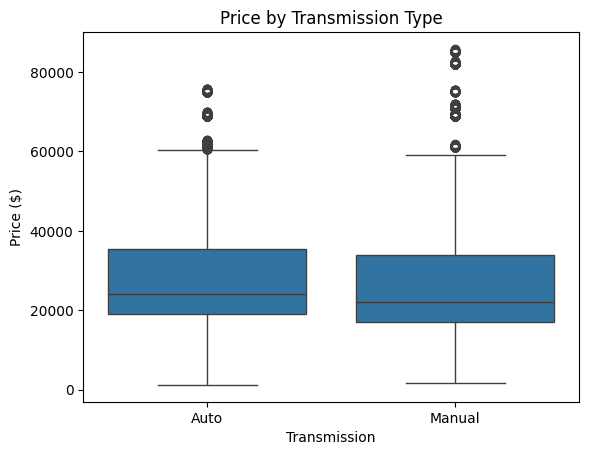

In [ ]:
# Price by Transmission type

sns.boxplot(data=df, x='Transmission', y='Price ($)')

plt.title('Price by Transmission Type')

plt.show()

## Insight: Price by Transmission Type
Auto cars are slightly more expensive on average ($28,249) than
Manual ($27,915), but the bigger difference is in the median —
Auto ($24,000) vs Manual ($22,001). Auto dominates the premium
segment ($30K–$50K), while Manual has more budget buyers (<$15K).
Manual prices are more spread out (higher std dev of $15,863),
meaning Manual cars range from very cheap to very expensive.
Gender preference is identical across both transmission types.

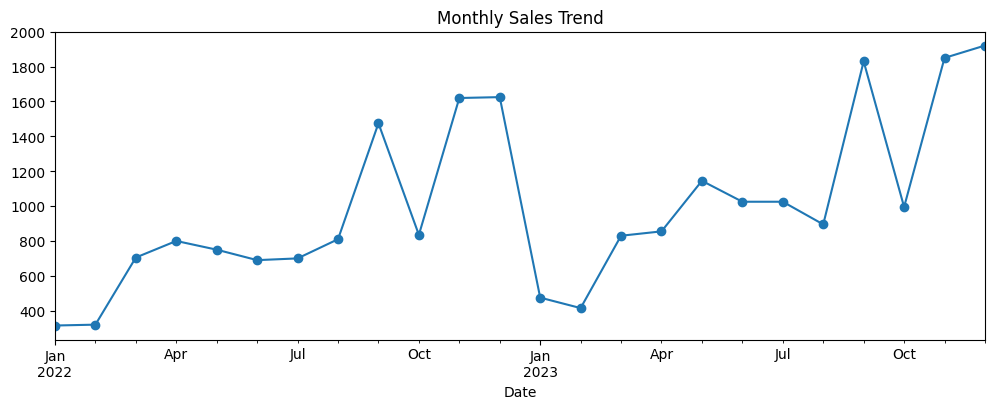

In [ ]:
# Monthly sales trend
monthly = df.groupby(['Year', 'Month'])['Car_id'].count().reset_index()
monthly.columns = ['Year', 'Month', 'Sales_Count']

df.groupby(df['Date'].dt.to_period('M'))['Car_id'].count()\
  .plot(figsize=(12,4), marker='o')
plt.title('Monthly Sales Trend')
plt.show()

## Monthly Sales Trend
**Key Insight:** Sales peak in November, December, and September.
January and February have the lowest sales.
**Implication:** Promotions and discounts should be planned for
Jan-Feb to boost slow-season sales. Stock up inventory before Sep-Dec.


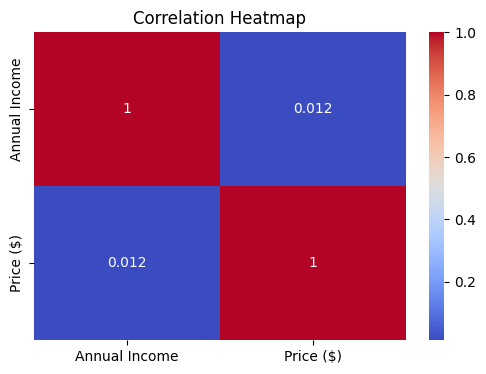

In [ ]:
# Only numeric columns
plt.figure(figsize=(6,4))
sns.heatmap(df[['Annual Income', 'Price ($)']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Insight: Correlation Heatmap
The dataset has only 3 numeric columns: Annual Income, Price ($),
and Phone. The correlation between Annual Income and Price is only
0.012 — essentially no relationship. This means customers across
all income levels spend similar amounts on cars. Phone is just an
identifier with no analytical value. Since no strong correlations
exist, car buying behavior in this dataset is driven by non-numeric
factors like brand, body style, and region — not income.